In [1]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
#data loading

data1 = pd.read_csv('train.csv')
data2 = pd.read_csv('test.csv')

train_df = data1.copy()
test_df = data2.copy()

print("First 5 rows of train_df: \n", train_df.head())

print("First 5 rows of test_df: \n", test_df.head())

First 5 rows of train_df: 
    id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0              

In [3]:
train_df = train_df.drop(columns=['id'], axis=1)

test_id_placeholder = test_df['id']
test_df = test_df.drop(columns=['id'], axis=1)

In [4]:
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

In [5]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

X = train_df.drop(columns='loan_paid_back')
y = train_df['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
cat_model = CatBoostClassifier(cat_features=cat_cols)

cat_model.fit(X_train, y_train)

Learning rate set to 0.143205
0:	learn: 0.5405242	total: 394ms	remaining: 6m 33s
1:	learn: 0.4433729	total: 601ms	remaining: 5m
2:	learn: 0.3802827	total: 825ms	remaining: 4m 34s
3:	learn: 0.3410668	total: 1.05s	remaining: 4m 22s
4:	learn: 0.3153787	total: 1.27s	remaining: 4m 13s
5:	learn: 0.2976656	total: 1.53s	remaining: 4m 13s
6:	learn: 0.2869880	total: 1.73s	remaining: 4m 4s
7:	learn: 0.2783549	total: 1.99s	remaining: 4m 6s
8:	learn: 0.2725982	total: 2.18s	remaining: 3m 59s
9:	learn: 0.2684360	total: 2.41s	remaining: 3m 58s
10:	learn: 0.2655688	total: 2.63s	remaining: 3m 56s
11:	learn: 0.2634373	total: 2.84s	remaining: 3m 53s
12:	learn: 0.2613712	total: 3.06s	remaining: 3m 52s
13:	learn: 0.2598790	total: 3.28s	remaining: 3m 51s
14:	learn: 0.2589231	total: 3.52s	remaining: 3m 51s
15:	learn: 0.2582219	total: 3.76s	remaining: 3m 51s
16:	learn: 0.2578017	total: 3.99s	remaining: 3m 50s
17:	learn: 0.2572070	total: 4.21s	remaining: 3m 49s
18:	learn: 0.2567331	total: 4.43s	remaining: 3m 48

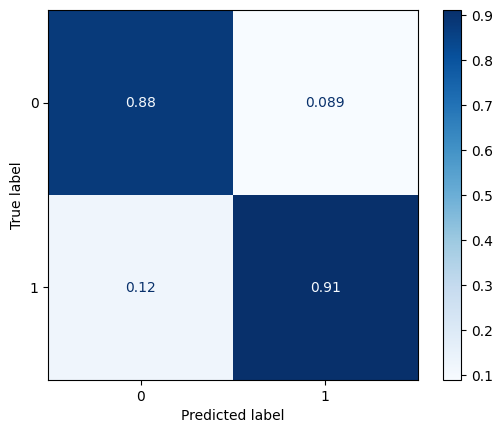

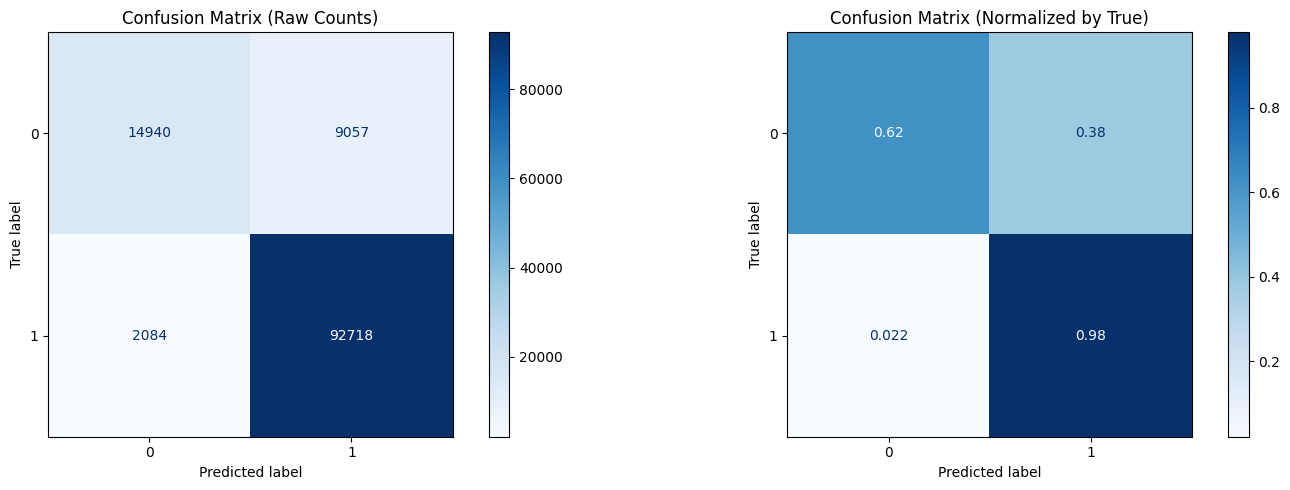

In [7]:
y_true = y_test

y_pred = cat_model.predict(X_test)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred, normalize='pred')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

# Confusion matrix with different normalization options
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Raw counts
cm_raw = confusion_matrix(y_true, y_pred)
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw)
disp_raw.plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix (Raw Counts)')

# Normalized by true labels (shows recall)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(ax=ax2, cmap='Blues')
ax2.set_title('Confusion Matrix (Normalized by True)')

plt.tight_layout()
plt.show()


In [8]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Basic metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-Score:", f1_score(y_true, y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.9062197493244892
Precision: 0.9110095799557848
Recall: 0.9780173414062995
F1-Score: 0.9433250075034211

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.62      0.73     23997
         1.0       0.91      0.98      0.94     94802

    accuracy                           0.91    118799
   macro avg       0.89      0.80      0.84    118799
weighted avg       0.90      0.91      0.90    118799



In [ ]:
# X_submission = test_df.copy()

# test_pred = cat_model.predict(test_df)

# submission_df = pd.DataFrame({
#     "id": test_id_placeholder,
#     "loan_paid_back": test_pred
# })

# submission_df.to_csv('submission2.csv',index=False)
# print("Success!")

Success!


In [14]:
from sklearn.model_selection import StratifiedKFold,train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
import optuna

In [15]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2500),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-3, 10.0),
        'random_state': 42,
        'eval_metric': 'AUC',
        'verbose': 0,
        'early_stopping_rounds': 50,
        'task_type': 'CPU',
        'devices': '0'
    }
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=test_pool)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    return roc_auc

In [17]:
study = optuna.create_study(direction='maximize')

study.optimize(
    objective,
    n_trials=20,           
    timeout=1800,        
    show_progress_bar=True
)

print(f"Best score: {study.best_value}")
print(f"Best params: {study.best_params}")

[I 2025-11-03 21:41:47,176] A new study created in memory with name: no-name-5baeb55f-9fd3-4d57-bfbf-5f47ec5962da
Best trial: 0. Best value: 0.921226:   5%|▌         | 1/20 [02:18<43:48, 138.33s/it, 138.33/1800 seconds]

[I 2025-11-03 21:44:05,508] Trial 0 finished with value: 0.9212259297367904 and parameters: {'iterations': 523, 'learning_rate': 0.0651019193794648, 'depth': 6, 'l2_leaf_reg': 2.2469978822189223}. Best is trial 0 with value: 0.9212259297367904.


Best trial: 1. Best value: 0.92161:  10%|█         | 2/20 [08:17<1:20:24, 268.03s/it, 497.16/1800 seconds]

[I 2025-11-03 21:50:04,333] Trial 1 finished with value: 0.9216098717050503 and parameters: {'iterations': 1177, 'learning_rate': 0.04255736820083819, 'depth': 10, 'l2_leaf_reg': 0.004092271609028882}. Best is trial 1 with value: 0.9216098717050503.


Best trial: 1. Best value: 0.92161:  15%|█▌        | 3/20 [22:35<2:32:19, 537.63s/it, 1355.60/1800 seconds]

...

[I 2025-11-03 22:07:55,238] Trial 3 finished with value: 0.9173687361433882 and parameters: {'iterations': 756, 'learning_rate': 0.012885442733389488, 'depth': 7, 'l2_leaf_reg': 0.0011063456744469053}. Best is trial 1 with value: 0.9216098717050503.


Best trial: 4. Best value: 0.922059:  25%|██▌       | 5/20 [29:55<1:25:53, 343.55s/it, 1795.11/1800 seconds]

[I 2025-11-03 22:11:42,283] Trial 4 finished with value: 0.9220594745042764 and parameters: {'iterations': 1294, 'learning_rate': 0.08643365545014996, 'depth': 9, 'l2_leaf_reg': 0.003110822918409706}. Best is trial 4 with value: 0.9220594745042764.


Best trial: 5. Best value: 0.923164:  30%|███       | 6/20 [41:27<1:36:43, 414.53s/it, 2487.16/1800 seconds]

[I 2025-11-03 22:23:14,338] Trial 5 finished with value: 0.9231643299870758 and parameters: {'iterations': 2089, 'learning_rate': 0.04363991799567954, 'depth': 8, 'l2_leaf_reg': 0.016446005747259584}. Best is trial 5 with value: 0.9231643299870758.
Best score: 0.9231643299870758
Best params: {'iterations': 2089, 'learning_rate': 0.04363991799567954, 'depth': 8, 'l2_leaf_reg': 0.016446005747259584}


In [18]:
study.best_params

{'iterations': 2089,
 'learning_rate': 0.04363991799567954,
 'depth': 8,
 'l2_leaf_reg': 0.016446005747259584}

In [21]:
from sklearn.model_selection import cross_val_score

In [23]:
params = {
    'iterations': 2089,
 'learning_rate': 0.04363991799567954,
 'depth': 8,
 'l2_leaf_reg': 0.016446005747259584
}

hyper_cat = CatBoostClassifier(**params, cat_features=cat_cols)

cv_res = cross_val_score(hyper_cat, X_train, y_train, cv=3, scoring='neg_log_loss')

print(f"Final CV scores: {cv_res}")
print(f"Mean CV score: {cv_res.mean():.4f} ± {cv_res.std():.4f}")

hyper_cat.fit(X_train, y_train)

0:	learn: 0.6405424	total: 205ms	remaining: 7m 7s
1:	learn: 0.5930410	total: 424ms	remaining: 7m 22s
2:	learn: 0.5534621	total: 651ms	remaining: 7m 32s
3:	learn: 0.5173146	total: 850ms	remaining: 7m 23s
4:	learn: 0.4867579	total: 1.05s	remaining: 7m 18s
5:	learn: 0.4598633	total: 1.24s	remaining: 7m 9s
6:	learn: 0.4370762	total: 1.49s	remaining: 7m 22s
7:	learn: 0.4176635	total: 1.69s	remaining: 7m 18s
8:	learn: 0.3996259	total: 1.88s	remaining: 7m 13s
9:	learn: 0.3839907	total: 2.08s	remaining: 7m 11s
10:	learn: 0.3703663	total: 2.27s	remaining: 7m 8s
11:	learn: 0.3579258	total: 2.48s	remaining: 7m 9s
12:	learn: 0.3470514	total: 2.67s	remaining: 7m 6s
13:	learn: 0.3378026	total: 2.87s	remaining: 7m 5s
14:	learn: 0.3295154	total: 3.08s	remaining: 7m 6s
15:	learn: 0.3218458	total: 3.28s	remaining: 7m 4s
16:	learn: 0.3151663	total: 3.47s	remaining: 7m 2s
17:	learn: 0.3091571	total: 3.67s	remaining: 7m 1s
18:	learn: 0.3039407	total: 3.84s	remaining: 6m 57s
19:	learn: 0.2995870	total: 4.06

In [ ]:
# X_submission = test_df.copy()

# test_pred = hyper_cat.predict(X_submission)

# submission_df = pd.DataFrame({
#     "id": test_id_placeholder,
#     "loan_paid_back": test_pred
# })

# submission_df.to_csv('submission4.csv',index=False)
# print("Success!")

Success!
